## Nombre: Nathaly Bravo
## 06/07/2026
## Métodos Númericos 

# Tarea 06 Serie de Taylor y Polinomios de Lagrange

##### 1. Determine el orden de la mejor aproximación para las siguientes funciones, usando la Serie de Taylor y el Polinomio de Lagrange:


a) $\dfrac{1}{25x^2+1}, \ x_0 = 0$

$$
f(x)=\frac{1}{25x^2+1}
$$


Los polinomios de aproximación de Taylor:

$$
P_0(x)=1
$$

$$
P_1(x)=1
$$

$$
P_2(x)=1-25x^2
$$

$$P_3(x) = 1 - 25x^2$$

$$
P_4(x)=1-25x^2+625x^4
$$




In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

In [3]:
import sympy as sp

x = sp.Symbol('x')
f = 1/(1+25*x**2)

derivs = [f.diff(x, k) for k in range(5)]
valores_en_0 = [expr.subs(x, 0) for expr in derivs]

def taylor_serie(x0, grado):
    pol = 0
    for k in range(grado + 1):
        termino = valores_en_0[k] * (x-x0)**k / sp.factorial(k)
        pol += termino
    return pol

x0 = 0
max_ordem = 4

for n in range(max_ordem + 1):
    t = taylor_serie(x0, n)
    print(f"Grado {n} : {sp.simplify(t)}")

Grado 0 : 1
Grado 1 : 1
Grado 2 : 1 - 25*x**2
Grado 3 : 1 - 25*x**2
Grado 4 : 625*x**4 - 25*x**2 + 1


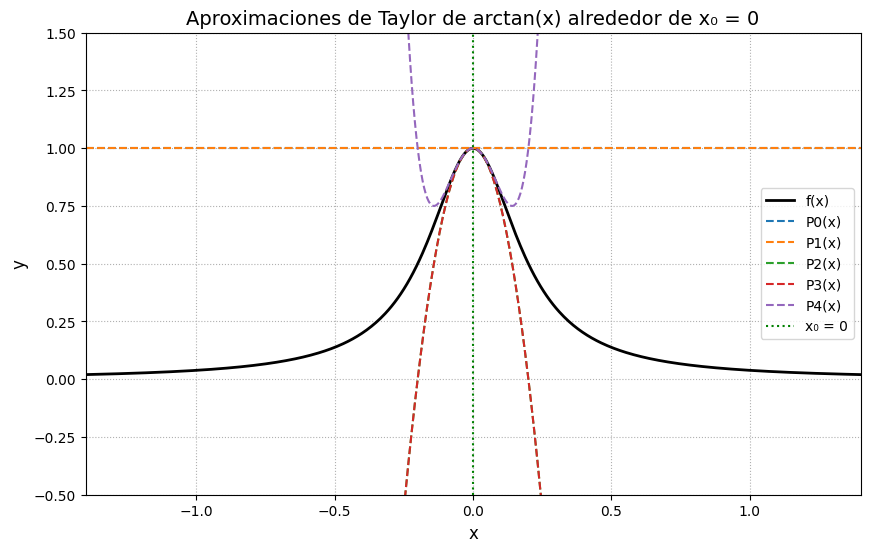

In [12]:
import numpy as np
import matplotlib.pyplot as plt

x_min = -1.4
x_max = 1.4
y_min = -0.5
y_max = 1.5
num_puntos = 500

x0 = 0

def f_original(x):
    return 1 / (25*x**2 + 1)

def P0(x):
    return np.ones_like(x)

def P1(x):
    return np.ones_like(x)

def P2(x):
    return 1 - 25*(x - x0)**2

def P3(x):
    return 1 - 25*(x - x0)**2

def P4(x):
    return 1 - 25*(x - x0)**2 + 625*(x - x0)**4

x = np.linspace(x_min, x_max, num_puntos)

plt.figure(figsize=(10, 6))

plt.plot(x, f_original(x), 'k', label='f(x)', linewidth=2)
plt.plot(x, P0(x), '--', label='P0(x)')
plt.plot(x, P1(x), '--', label='P1(x)')
plt.plot(x, P2(x), '--', label='P2(x)')
plt.plot(x, P3(x), '--', label='P3(x)')
plt.plot(x, P4(x), '--', label='P4(x)')

plt.axvline(x=x0, color='green', linestyle=':', label=f'x₀ = {x0}')

plt.title(f"Aproximaciones de Taylor de arctan(x) alrededor de x₀ = {x0}", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)

plt.grid(True, linestyle=':')
plt.legend()
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.show()

### Polinomio de Lagrange

$$f(x) = \frac{1}{25x^2 + 1}$$

$$x_0 = 0$$

$$(-0.4,\ 0.2),\ (-0.2,\ 0.5),\ (0,\ 1),\ (0.2,\ 0.5),\ (0.4,\ 0.2)$$

**Polinomio:**

$$P(x) = \frac{1}{2}L_0(x) + 1 \cdot L_1(x) + \frac{1}{2}L_2(x) + \frac{1}{5}L_3(x)$$

**Bases de Lagrange:**

$$L_0(x) = \frac{x(x - 0.2)(x - 0.4)}{(-0.2 - 0)(-0.2 - 0.2)(-0.2 - 0.4)} = \frac{x(x - 0.2)(x - 0.4)}{-0.048}$$

$$L_1(x) = \frac{(x + 0.2)(x - 0.2)(x - 0.4)}{(0 + 0.2)(0 - 0.2)(0 - 0.4)} = \frac{(x + 0.2)(x - 0.2)(x - 0.4)}{0.016}$$

$$L_2(x) = \frac{(x + 0.2)x(x - 0.4)}{(0.2 + 0.2)(0.2 - 0)(0.2 - 0.4)} = \frac{(x + 0.2)x(x - 0.4)}{-0.016}$$

$$L_3(x) = \frac{(x + 0.2)x(x - 0.2)}{(0.4 + 0.2)(0.4 - 0)(0.4 - 0.2)} = \frac{(x + 0.2)x(x - 0.2)}{0.048}$$

**Sustituyendo:**

$$P(x) = \frac{1}{2}\left(\frac{x(x - 0.2)(x - 0.4)}{-0.048}\right) + \left(\frac{(x + 0.2)(x - 0.2)(x - 0.4)}{0.016}\right) + \frac{1}{2}\left(\frac{(x + 0.2)x(x - 0.4)}{-0.016}\right) + \frac{1}{5}\left(\frac{(x + 0.2)x(x - 0.2)}{0.048}\right)$$

**Resultado:**

$$\boxed{P(x) = 25x^3 - \frac{25}{2}x^2 - x + 1}$$

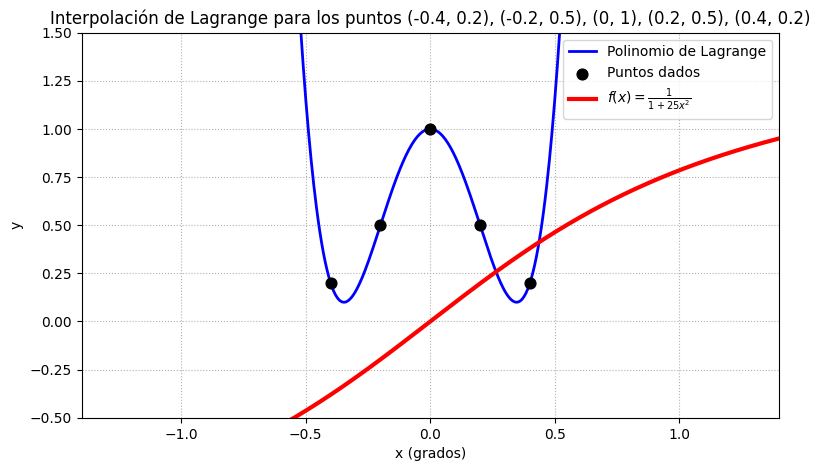

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

x_pts = np.array([-0.4, -0.2, 0.0, 0.2, 0.4])
y_pts = np.array([0.2, 0.5, 1.0, 0.5, 0.2])

P = lagrange(x_pts, y_pts)

x_min, x_max = -1.4, 1.4
y_min, y_max = -0.5, 1.5

x_vals = np.linspace(x_min, x_max, 800)
y_vals = P(x_vals)

plt.figure(figsize=(9, 5))
plt.plot(x_vals, y_vals, label='Polinomio de Lagrange', color='blue', linewidth=2)
plt.scatter(x_pts, y_pts, color='black', label='Puntos dados', zorder=5, s=60)
plt.plot(x, f_original(x),
         label=r'$f(x)=\frac{1}{1+25x^2}$',
         color='red', linewidth=3)

plt.xlabel("x (grados)")
plt.ylabel("y")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title("Interpolación de Lagrange para los puntos (-0.4, 0.2), (-0.2, 0.5), (0, 1), (0.2, 0.5), (0.4, 0.2)")
plt.grid(True, linestyle=':')
plt.legend()
plt.show()



### Caso 2

$$f(x) = \arctan(x)$$

$$x_0 = 1$$

Los polinomios de aproximación de Taylor son:

$$P_0(x) = \frac{\pi}{4}$$
$$P_1(x) = \frac{x}{2} - \frac{1}{2} + \frac{\pi}{4}$$
$$P_2(x) = -\frac{x^2}{4} + x - \frac{3}{4} + \frac{\pi}{4}$$
$$P_3(x) = \frac{x^3}{12} - \frac{x^2}{2} + \frac{5x}{4} - \frac{5}{6} + \frac{\pi}{4}$$
$$P_4(x) = \frac{x^3}{12} - \frac{x^2}{2} + \frac{5x}{4} - \frac{5}{6} + \frac{\pi}{4}$$

In [6]:
import sympy as sp

x = sp.Symbol('x')

f = sp.atan(x)

derivs = [f.diff(x, k) for k in range(5)]

x0 = 1

valores_en_x0 = [expr.subs(x, x0) for expr in derivs]

# taylor
def taylor_serie(x0, grado):
    pol = 0
    for k in range(grado + 1):
        termino = valores_en_x0[k] * (x - x0)**k / sp.factorial(k)
        pol += termino
    return sp.simplify(pol)

# Hasta grado 4
max_orden = 4

for n in range(max_orden + 1):
    t = taylor_serie(x0, n)
    print(f"Grado {n}: {t}")

Grado 0: pi/4
Grado 1: x/2 - 1/2 + pi/4
Grado 2: -x**2/4 + x - 3/4 + pi/4
Grado 3: x**3/12 - x**2/2 + 5*x/4 - 5/6 + pi/4
Grado 4: x**3/12 - x**2/2 + 5*x/4 - 5/6 + pi/4


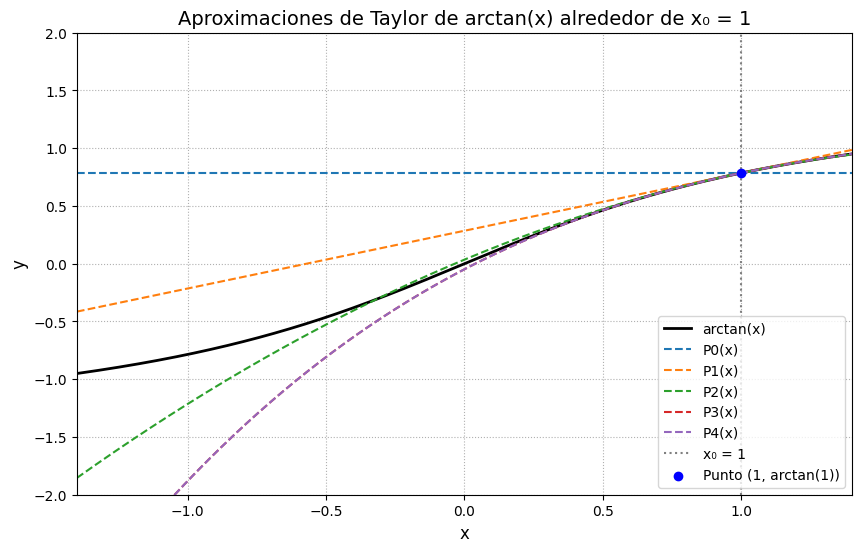

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Límites de la gráfica
x_min = -1.4
x_max = 1.4
y_min = -2
y_max = 2
num_puntos = 500

x0 = 1

def f_original(x):
    return np.arctan(x)

def P0(x):
    return (np.pi / 4) * np.ones_like(x)

def P1(x):
    return x/2 - 1/2 + np.pi/4

def P2(x):
    return -x**2/4 + x - 3/4 + np.pi/4

def P3(x):
    return x**3/12 - x**2/2 + 5*x/4 - 5/6 + np.pi/4

def P4(x):
    return x**3/12 - x**2/2 + 5*x/4 - 5/6 + np.pi/4

x = np.linspace(x_min, x_max, num_puntos)

plt.figure(figsize=(10, 6))

plt.plot(x, f_original(x), 'k', label='arctan(x)', linewidth=2)
plt.plot(x, P0(x), '--', label='P0(x)')
plt.plot(x, P1(x), '--', label='P1(x)')
plt.plot(x, P2(x), '--', label='P2(x)')
plt.plot(x, P3(x), '--', label='P3(x)')
plt.plot(x, P4(x), '--', label='P4(x)')

plt.axvline(x=x0, color='gray', linestyle=':', label=f'x₀ = {x0}')
plt.scatter(x0, f_original(x0), color='blue', zorder=5, label=f'Punto ({x0}, arctan({x0}))')

plt.title(f"Aproximaciones de Taylor de arctan(x) alrededor de x₀ = {x0}", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)

plt.grid(True, linestyle=':')
plt.legend()
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.show()

### Polinomio de Lagrange

$$f(x) = \arctan(x)$$

$$\left(-1,\ -\frac{\pi}{4}\right),\ (-0.5,\ -0.463648),\ (0,\ 0),\ (0.5,\ 0.463648),\ \left(1,\ \frac{\pi}{4}\right)$$

**Polinomio:**

$$P(x) = 0 \cdot L_0(x) + \arctan(0.5)L_1(x) + \frac{\pi}{4}L_2(x) + \arctan(1.5)L_3(x)$$

**Bases de Lagrange:**

$$L_0(x) = \frac{(x - 0.5)(x - 1)(x - 1.5)}{(0 - 0.5)(0 - 1)(0 - 1.5)} = \frac{(x - 0.5)(x - 1)(x - 1.5)}{-0.75}$$

$$L_1(x) = \frac{x(x - 1)(x - 1.5)}{(0.5 - 0)(0.5 - 1)(0.5 - 1.5)} = \frac{x(x - 1)(x - 1.5)}{0.25}$$

$$L_2(x) = \frac{x(x - 0.5)(x - 1.5)}{(1 - 0)(1 - 0.5)(1 - 1.5)} = \frac{x(x - 0.5)(x - 1.5)}{-0.25}$$

$$L_3(x) = \frac{x(x - 0.5)(x - 1)}{(1.5 - 0)(1.5 - 0.5)(1.5 - 1)} = \frac{x(x - 0.5)(x - 1)}{0.75}$$

**Sustituyendo:**

$$P(x) = \arctan(0.5)\left(\frac{x(x - 1)(x - 1.5)}{0.25}\right) + \frac{\pi}{4}\left(\frac{x(x - 0.5)(x - 1.5)}{-0.25}\right) + \arctan(1.5)\left(\frac{x(x - 0.5)(x - 1)}{0.75}\right)$$

**Resultado:**

$$\boxed{P(x) \approx 0.0233894x^3 - 0.318878x^2 + 1.080887x}$$

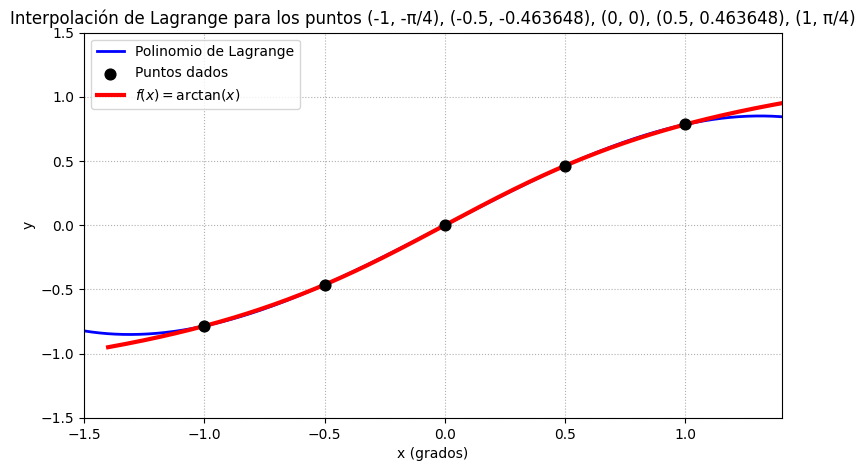

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

x_pts = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
y_pts = np.array([-np.pi/4, -0.463648, 0, 0.463648, np.pi/4])

P = lagrange(x_pts, y_pts)

x_min, x_max = -1.5, 1.4
y_min, y_max = -1.5, 1.5

x_vals = np.linspace(x_min, x_max, 800)
y_vals = P(x_vals)

plt.figure(figsize=(9, 5))
plt.plot(x_vals, y_vals, label='Polinomio de Lagrange', color='blue', linewidth=2)
plt.scatter(x_pts, y_pts, color='black', label='Puntos dados', zorder=5, s=60)
plt.plot(x, f_original(x),
         label=r'$f(x)=\arctan(x)$',
         color='red', linewidth=3)

plt.xlabel("x (grados)")
plt.ylabel("y")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title("Interpolación de Lagrange para los puntos (-1, -π/4), (-0.5, -0.463648), (0, 0), (0.5, 0.463648), (1, π/4)")
plt.grid(True, linestyle=':')
plt.legend()
plt.show()